# Fast convolution

So, the english is not very good, I will improve that

In [4]:
import itertools

import sympy as sy
import numpy as np
import scipy as sc

In [5]:
import fitz

In [6]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [7]:
from fast_convolution import toom_cook, recursive_log2, g2bg

In [8]:
from utils import plot_pdf

In [9]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

Size of vectors

In [128]:
d_num = 6
g_num = 3

Example of vectors for the convolution

In [129]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2, 3, 4, 5, 6] [1, 2, 3]


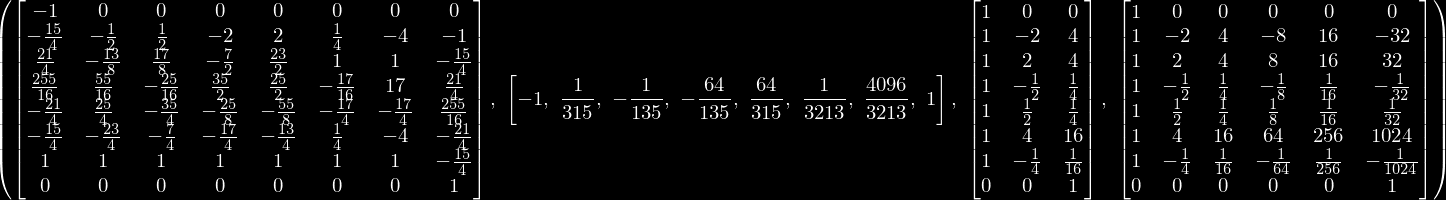

In [136]:
c_mtx, cq, b_mtx, a_mtx = toom_cook(d_num, g_num, [0, -2, 2, -1/2, 1/2, 4, -1/4, np.inf])
c_mtx, cq, b_mtx, a_mtx

In [117]:
def recursive_log2(n):
    if n == 0:
        return 0, []
    if isinstance(n, sy.Rational):
        n = n.q
        exp_sig = -1
    else:
        exp_sig = 1

    base_sig = -1 if n < 0 else 1
    exp = [exp_sig * e for e, b in enumerate(bin(n)[2::][::-1]) if b == '1']
    return base_sig, exp


In [118]:
c_lst = c_mtx.tolist()
c_lst2 = [[None for c in range(len(c_lst[0]))] for r in range(len(c_lst))]
for r in range(len(c_lst)):
    for c in range(len(c_lst[0])):
        c_lst2[r][c] = recursive_log2(c_lst[r][c])
        print(c_lst2[r][c])
c_lst2

(1, [0])
(0, [])
(0, [])
(0, [])
(0, [])
(0, [])
(0, [])
(1, [-1])
(1, [-1])
(1, [0])
(1, [0])
(1, [0])
(1, [-2])
(1, [-2])
(1, [-2])
(1, [0])
(1, [0])
(0, [])
(0, [])
(1, [0])
(1, [0])
(1, [-1])
(1, [-1])
(1, [-2])
(1, [0])
(1, [0])
(1, [0])
(1, [0])
(1, [0])
(0, [])
(0, [])
(0, [])
(0, [])
(0, [])
(0, [])
(1, [0])


In [18]:
bg_mtx = g2bg(cq, b_mtx, g_values)

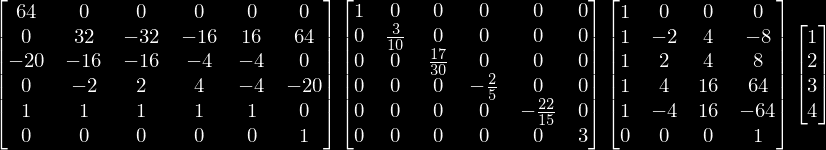

In [122]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(d_values))
s

Comparing numerical outputs from direct and winograd method

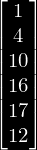

In [20]:
sy.Matrix(np.convolve(d_values, g_values))

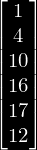

In [21]:
sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(d_values), evaluate=True)